<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/01b_bayesian_samplers.ipynb)

# Extension lab: how Bayesian samplers explore a posterior

**FQCP 2026 · Optional sampler laboratory**

This page is not part of the live route. The Bayesian primer established the
scientific ingredients first; this lab changes only the numerical method used
to explore the same two-parameter posterior.

> **Main message**
>
> A sampler does not define the posterior and cannot repair a wrong signal,
> noise model, likelihood, or prior. It is a numerical engine for exploring the
> posterior those choices define.

**Animation guide.** Each animation answers a different numerical question:
Section 2 shows a random walk mixing along a correlated ridge; Section 3 shows
nested sampling trading prior volume for likelihood; Section 5 shows one NUTS
trajectory; Section 6 shows where a variational family stops short. Do not
read smooth motion as evidence of convergence--use the diagnostics beside it.

## Which tool answers which question?

| Method | What it returns | Strength | Main caution |
| --- | --- | --- | --- |
| grid / rejection sampling | posterior density or independent draws | transparent; excellent for teaching and checks | cost grows exponentially with dimension |
| random-walk MCMC | posterior draws | simple and needs no gradients | correlated draws; slow on narrow ridges |
| HMC / NUTS | posterior draws | efficient in many differentiable dimensions | needs gradients, scaling, warm-up, and convergence checks |
| nested sampling | posterior draws and evidence | designed for evidence and separated modes | constrained sampling can become expensive |
| variational inference | fitted approximate posterior | very fast after optimisation | the approximation can miss modes or underestimate uncertainty |
| simulation-based inference | amortised approximate posterior | extremely fast at inference time | inherits the simulator and training-distribution assumptions |

In production code, use a tested library such as NumPyro, Stan, Bilby, or
dynesty. The short NumPy implementations below expose the mechanics so that
diagnostics and failure modes are intelligible; they are not production
replacements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")


def show_animation(animation):
    try:
        return display(HTML(animation.to_html5_video()))
    except RuntimeError:
        return display(HTML(animation.to_jshtml()))


true_parameters = {"m": 0.5, "c": 0.2}
sigma = 3.0
time = np.linspace(0, 10, 100)


def signal_model(time, m, c):
    return m * time + c


data = signal_model(time, **true_parameters) + rng.normal(0, sigma, time.size)


def log_likelihood(m, c):
    residual = data - signal_model(time, m, c)
    return -0.5 * np.sum((residual / sigma) ** 2 + np.log(2 * np.pi * sigma**2))


m_grid = np.linspace(0, 1.5, 141)
c_grid = np.linspace(-5, 5, 161)
M, C = np.meshgrid(m_grid, c_grid, indexing="ij")
logL = np.array([[log_likelihood(m, c) for c in c_grid] for m in m_grid])
posterior = np.exp(logL - logL.max())
posterior /= np.trapezoid(np.trapezoid(posterior, c_grid, axis=1), m_grid)
p_m = np.trapezoid(posterior, c_grid, axis=1)
p_c = np.trapezoid(posterior, m_grid, axis=0)


def log_trapezoid_exp(log_values, grid, axis=-1):
    reference = np.max(log_values)
    integral = np.trapezoid(np.exp(log_values - reference), grid, axis=axis)
    return reference + np.log(integral)


log_z_free_intercept = log_trapezoid_exp(
    np.array([log_trapezoid_exp(logL[row], c_grid) for row in range(len(m_grid))]),
    m_grid,
) - np.log((m_grid[-1] - m_grid[0]) * (c_grid[-1] - c_grid[0]))

print("Exact grid ready; it will be the reference for every approximation below.")

Exact grid ready; it will be the reference for every approximation below.


## 1. Why replace the grid?

The live lesson used a grid because it makes the prior, likelihood, and
posterior visible. Real gravitational-wave problems have too many parameters
for a grid. The next two sections retain readable teaching implementations of
the two main alternatives: Metropolis--Hastings for posterior samples and
nested sampling for posterior samples plus evidence.

## 2. Random-walk Metropolis--Hastings

- A grid with $n$ points per axis and $D$ parameters costs $n^D$ likelihood
  evaluations.

$$
\text{cost}=n^D,\qquad D_{\rm BBH}\approx15,\ n=20
\ \Rightarrow\ 20^{15}\approx3\times10^{19}.
$$

- At 1 ms per waveform that is about a **billion years**.
- The posterior occupies a vanishingly small fraction of that volume, so almost
  every grid point is wasted.
- Stochastic samplers spend their effort where the posterior has mass. The next
  three sections build the two that dominate gravitational-wave work:
  **MCMC** for parameters, **nested sampling** for evidence.

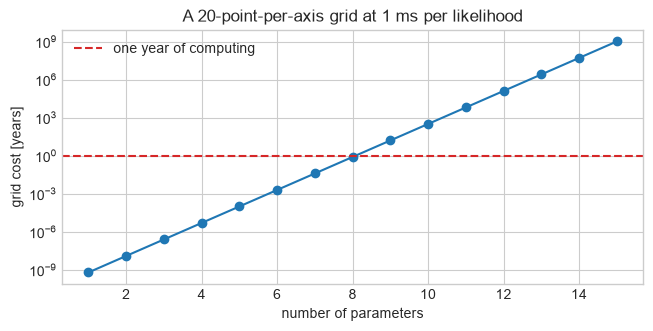

Two parameters: 400 evaluations
Fifteen parameters: 3.28e+19 evaluations


In [2]:
dimensions = np.arange(1, 16)
grid_cost = 20.0**dimensions
seconds_per_likelihood = 1e-3

fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.semilogy(dimensions, grid_cost * seconds_per_likelihood / (3600 * 24 * 365), "o-")
ax.axhline(1, color="C3", ls="--", label="one year of computing")
ax.set(
    xlabel="number of parameters",
    ylabel="grid cost [years]",
    title="A 20-point-per-axis grid at 1 ms per likelihood",
)
ax.legend()
plt.show()

print(f"Two parameters: {20**2:,} evaluations")
print(f"Fifteen parameters: {20**15:.2e} evaluations")

### Metropolis-Hastings in twelve lines

From the current point $\theta$, repeat:

$$
\theta'=\theta+\mathcal N(0,\Sigma_{\rm prop}),\qquad
\alpha=\min\left[1,\;
\frac{\mathcal L(\theta')\,\pi(\theta')}{\mathcal L(\theta)\,\pi(\theta)}\right],
$$

accept $\theta'$ with probability $\alpha$, otherwise **store $\theta$ again**.

- Only the *ratio* is needed, so the evidence $\mathcal Z$ cancels. This is why
  MCMC works when the normalisation is unknown.
- Repeating a rejected point is not a bug: it is how the chain accumulates
  density where the posterior is large.
- The output is a set of **correlated** draws whose histogram converges to the
  posterior. Correlated is fine; it just costs effective samples, which the
  diagnostics section below makes visible.
- Uphill moves are always accepted; downhill moves are accepted sometimes. That
  is what stops the chain collapsing onto the maximum-likelihood point.

In [3]:
PRIOR_BOX = np.array([[0.0, 1.5], [-5.0, 5.0]])  # rows: m, c


def log_posterior(theta):
    """Unnormalised log posterior: flat prior inside the box, zero outside."""
    if np.any(theta < PRIOR_BOX[:, 0]) or np.any(theta > PRIOR_BOX[:, 1]):
        return -np.inf
    return log_likelihood(theta[0], theta[1])


def metropolis(log_target, start, n_steps, step_size, rng):
    """Random-walk Metropolis. Returns the chain and the acceptance fraction."""
    chain = np.empty((n_steps, len(start)))
    current = np.asarray(start, dtype=float)
    current_logp = log_target(current)
    n_accepted = 0
    for step in range(n_steps):
        proposal = current + rng.normal(0.0, step_size)
        proposal_logp = log_target(proposal)
        if np.log(rng.uniform()) < proposal_logp - current_logp:
            current, current_logp = proposal, proposal_logp
            n_accepted += 1
        chain[step] = current
    return chain, n_accepted / n_steps


sampler_rng = np.random.default_rng(4)
chain, acceptance = metropolis(
    log_posterior,
    start=[1.35, -4.0],  # deliberately a bad starting guess
    n_steps=6000,
    step_size=np.array([0.12, 0.7]),
    rng=sampler_rng,
)
print(f"acceptance fraction: {acceptance:.2f}")
print(f"chain shape: {chain.shape}")

acceptance fraction: 0.29
chain shape: (6000, 2)


### Animation: watch the chain find the posterior

Two distinct phases to look for:

- **Burn-in** — a directed climb from the deliberately bad start in the corner,
  where the posterior is negligible. These samples describe where we started,
  not the posterior, so they are discarded.
- **Sampling** — the walker wanders up and down the degeneracy ridge. This is
  the part that is actually a draw from the posterior.

The trace panel on the right is the standard way to spot the transition.

In [4]:
frame_steps = np.arange(20, 1400, 26)
fig, (walk_ax, trace_ax) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72)
walk_ax.contour(m_grid, c_grid, posterior.T, levels=6, cmap="magma")
(path,) = walk_ax.plot([], [], lw=0.7, color="C0", alpha=0.8)
(head,) = walk_ax.plot([], [], "o", color="C3", ms=7)
walk_ax.plot(true_parameters["m"], true_parameters["c"], "c*", ms=12)
walk_ax.set(xlim=(0, 1.5), ylim=(-5, 5), xlabel="slope m", ylabel="intercept c")
(trace_line,) = trace_ax.plot([], [], lw=0.8, color="C0")
trace_ax.axhline(true_parameters["m"], color="k", ls="--")
trace_ax.set(xlim=(0, frame_steps[-1]), ylim=(0, 1.5), xlabel="step", ylabel="slope m")


def animate_chain(i):
    n = frame_steps[i]
    path.set_data(chain[:n, 0], chain[:n, 1])
    head.set_data([chain[n - 1, 0]], [chain[n - 1, 1]])
    trace_line.set_data(np.arange(n), chain[:n, 0])
    walk_ax.set_title(f"step {n}")
    return path, head, trace_line


chain_animation = FuncAnimation(
    fig, animate_chain, frames=len(frame_steps), interval=80
)
plt.close(fig)
show_animation(chain_animation)

### The proposal scale controls everything

A chain can be correct in principle and useless in practice:

- **Steps too small** — almost everything is accepted, but the walker crawls
  and never crosses the posterior. Watch the printed mean below: it is badly
  wrong, from code that has no bug.
- **Steps too large** — almost every proposal lands somewhere absurd and is
  rejected, so the chain sits still.
- **Well tuned** — acceptance around 0.2-0.3 for random-walk Metropolis.

Both failures look the same in the end: a chain that has not forgotten where it
started. `emcee`, `dynesty`, and `bilby` automate the tuning, but these failure
modes are exactly what their convergence diagnostics are looking for.

 too small: acceptance 0.94, posterior mean m = 0.807
well tuned: acceptance 0.29, posterior mean m = 0.479
 too large: acceptance 0.01, posterior mean m = 0.482


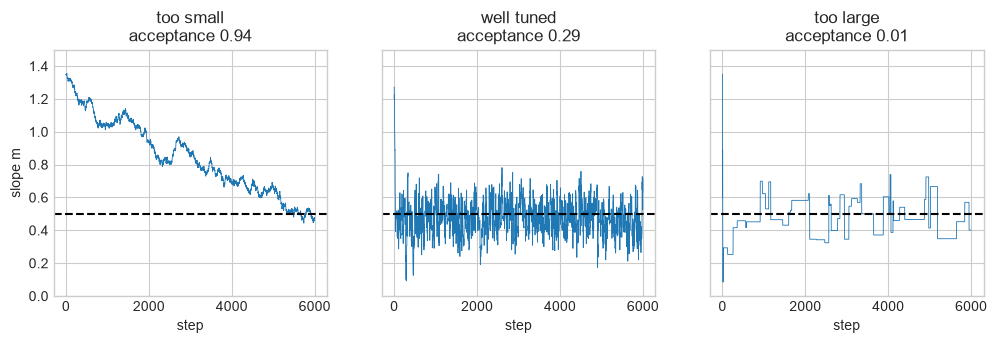

In [5]:
settings = [
    ("too small", np.array([0.004, 0.02])),
    ("well tuned", np.array([0.12, 0.7])),
    ("too large", np.array([1.2, 7.0])),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (label, step_size) in zip(axes, settings):
    trial_chain, trial_acceptance = metropolis(
        log_posterior, [1.35, -4.0], 6000, step_size, np.random.default_rng(4)
    )
    ax.plot(trial_chain[:, 0], lw=0.6)
    ax.axhline(true_parameters["m"], color="k", ls="--")
    ax.set(
        xlabel="step",
        title=f"{label}\nacceptance {trial_acceptance:.2f}",
    )
    print(
        f"{label:>10}: acceptance {trial_acceptance:.2f}, "
        f"posterior mean m = {trial_chain[500:, 0].mean():.3f}"
    )
axes[0].set_ylabel("slope m")
axes[0].set_ylim(0, 1.5)
plt.show()

### Diagnostics: burn-in and effective sample size

Consecutive samples are correlated, so $N$ stored samples are worth fewer than
$N$ independent draws. With autocorrelation $\rho(k)$ at lag $k$,

$$
N_{\rm eff}\simeq\frac{N}{1+2\sum_{k\ge1}\rho(k)},\qquad
\text{Monte Carlo error}\propto\frac{1}{\sqrt{N_{\rm eff}}}.
$$

- $N_{\rm eff}$, **not** the raw chain length, sets the error on every
  posterior summary you quote.
- A million highly correlated samples can carry less information than a
  thousand independent ones.
- Thinning (keeping every $k$-th sample) saves storage. It does not improve
  $N_{\rm eff}$, so it never buys accuracy.
- Rule of thumb: report a number only if $N_{\rm eff}$ is in the hundreds.

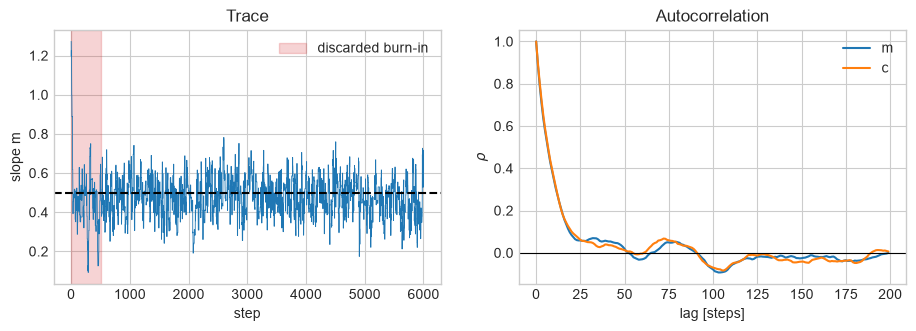

m: N = 5500, N_eff = 291
c: N = 5500, N_eff = 309


In [6]:
burn_in = 500
samples = chain[burn_in:]


def autocorrelation(x):
    """Normalised autocorrelation function of a 1D chain."""
    x = x - x.mean()
    acf = np.correlate(x, x, mode="full")[x.size - 1 :]
    return acf / acf[0]


def effective_sample_size(x):
    acf = autocorrelation(x)
    first_small = np.argmax(acf < 0.05)
    cutoff = acf.size if first_small == 0 else first_small
    return x.size / (1 + 2 * acf[1:cutoff].sum())


fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].plot(chain[:, 0], lw=0.6)
axes[0].axvspan(0, burn_in, color="C3", alpha=0.2, label="discarded burn-in")
axes[0].axhline(true_parameters["m"], color="k", ls="--")
axes[0].set(xlabel="step", ylabel="slope m", title="Trace")
axes[0].legend()
for index, name in enumerate(["m", "c"]):
    axes[1].plot(autocorrelation(samples[:, index])[:200], label=name)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(xlabel="lag [steps]", ylabel=r"$\rho$", title="Autocorrelation")
axes[1].legend()
plt.show()

for index, name in enumerate(["m", "c"]):
    print(
        f"{name}: N = {samples.shape[0]}, "
        f"N_eff = {effective_sample_size(samples[:, index]):.0f}"
    )

### The corner plot, and a check against the grid

A corner plot is the standard way to display a multi-dimensional posterior: 1D
marginals on the diagonal, 2D marginals below. Because this problem is small
enough to solve both ways, we can overlay the exact grid marginals in orange.
Agreement is the check that the sampler is doing its job, and it is the only
reason to trust the sampler on problems where no grid is possible.

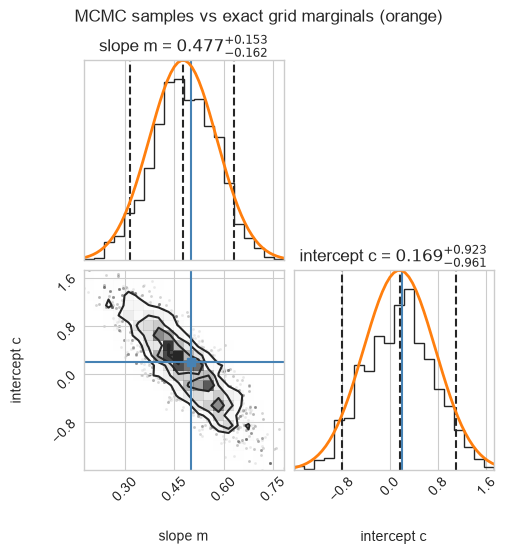

grid    : m = 0.4763
sampler : m = 0.4791


In [7]:
import subprocess
import sys

try:
    import corner
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "corner"])
    import corner

corner_figure = corner.corner(
    samples,
    labels=["slope m", "intercept c"],
    truths=[true_parameters["m"], true_parameters["c"]],
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3f",
)
corner_axes = np.array(corner_figure.axes).reshape(2, 2)
for axis, grid, marginal in [
    (corner_axes[0, 0], m_grid, p_m),
    (corner_axes[1, 1], c_grid, p_c),
]:
    # corner draws counts, not a density, so rescale the exact curve to match.
    axis.plot(grid, marginal * axis.get_ylim()[1] / marginal.max(), color="C1", lw=2)
corner_figure.suptitle("MCMC samples vs exact grid marginals (orange)", y=1.02)
plt.show()

print(f"grid    : m = {np.trapezoid(p_m * m_grid, m_grid):.4f}")
print(f"sampler : m = {samples[:, 0].mean():.4f}")

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/basics-corner-check.png" alt="expected output: basics-corner-check" style="max-width:100%">

</details>

## 3. Nested sampling and evidence

MCMC gives parameters but not $\mathcal Z$. Nested sampling gives both, by
reordering the integral along **prior volume**. Let $X(\lambda)$ be the
fraction of the prior with $\mathcal L>\lambda$. Then a $D$-dimensional
integral becomes a one-dimensional one:

$$
\mathcal Z=\int\mathcal L(\theta)\,\pi(\theta)\,d\theta
=\int_0^1\mathcal L(X)\,dX
\;\simeq\;\sum_i\mathcal L_i\,\Delta X_i .
$$

The algorithm:

1. Draw $N_{\rm live}$ points from the prior.
2. Delete the **worst** one and record its likelihood.
3. Replace it by a new draw from the prior, restricted to
   $\mathcal L>\mathcal L_{\rm worst}$.
4. Repeat. Each deletion shrinks the volume by a known factor,
   $X_i\approx e^{-i/N_{\rm live}}$.

- The likelihood threshold only ever rises, so the live points contract onto
  the peak. The animation below shows exactly this.
- Step 3 is the hard part in real problems, and it is what separates
  `MultiNest` (ellipsoids) from `PolyChord` and `dynesty` (slice sampling).
  Ours evolves a copy of a surviving point with a short constrained MCMC.
- Posterior samples come out free: the deleted points weighted by
  $\mathcal L_i\Delta X_i$.
- This is why Bayesian model comparison is practical in GW astronomy at all.

In [8]:
def nested_sampling(
    log_likelihood_fn, prior_box, n_live=250, n_iterations=1400, n_mcmc=25, rng=None
):
    """A minimal nested sampler with MCMC-based constrained replacement."""
    low, high = prior_box[:, 0], prior_box[:, 1]
    live = rng.uniform(low, high, size=(n_live, low.size))
    live_logl = np.array([log_likelihood_fn(point) for point in live])

    log_evidence = -np.inf
    dead_logl, dead_logw, snapshots = [], [], []

    for iteration in range(n_iterations):
        worst = np.argmin(live_logl)
        log_volume = -iteration / n_live
        log_shell = log_volume + np.log1p(-np.exp(-1.0 / n_live))
        log_evidence = np.logaddexp(log_evidence, live_logl[worst] + log_shell)
        dead_logl.append(live_logl[worst])
        dead_logw.append(log_shell)
        if iteration % 50 == 0:
            snapshots.append((live.copy(), log_volume, log_evidence))

        # Replace the worst point by evolving a copy of a surviving one.
        threshold = live_logl[worst]
        point = live[rng.integers(n_live)].copy()
        point_logl = log_likelihood_fn(point)
        proposal_scale = live.std(axis=0)
        for _ in range(n_mcmc):
            trial = point + rng.normal(0.0, proposal_scale)
            if np.all(trial > low) and np.all(trial < high):
                trial_logl = log_likelihood_fn(trial)
                if trial_logl > threshold:
                    point, point_logl = trial, trial_logl
        live[worst], live_logl[worst] = point, point_logl

    # Add the remaining live points as a final block.
    log_remaining = -n_iterations / n_live - np.log(n_live)
    log_evidence = np.logaddexp(
        log_evidence, np.logaddexp.reduce(live_logl) + log_remaining
    )
    return log_evidence, np.array(dead_logl), np.array(dead_logw), snapshots


log_z_nested, dead_logl, dead_logw, snapshots = nested_sampling(
    lambda point: log_likelihood(point[0], point[1]),
    PRIOR_BOX,
    rng=np.random.default_rng(7),
)

print(f"nested sampling log Z: {log_z_nested:.3f}")
print(f"grid log Z           : {log_z_free_intercept:.3f}")
print(f"difference           : {log_z_nested - log_z_free_intercept:+.3f}")

nested sampling log Z: -252.901


grid log Z           : -253.008
difference           : +0.107


### Animation: the live points contract onto the posterior

Each frame shows the surviving live points. They begin spread over the whole
prior and are squeezed into the high-likelihood ridge as the likelihood
threshold rises. The right panel shows the integrand $\mathcal{L}(X)$ against
$\log X$: the evidence is the area under it, and the visible bump is the
region of prior volume that actually contributes.

In [9]:
fig, (live_ax, mass_ax) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72)
live_ax.contour(m_grid, c_grid, posterior.T, levels=6, cmap="magma")
(live_points,) = live_ax.plot([], [], ".", color="C0", ms=3)
live_ax.set(xlim=(0, 1.5), ylim=(-5, 5), xlabel="slope m", ylabel="intercept c")

log_volume_axis = -np.arange(dead_logl.size) / 250
posterior_mass = np.exp(dead_logl + dead_logw - np.max(dead_logl + dead_logw))
mass_ax.plot(log_volume_axis, posterior_mass, color="0.7")
(mass_line,) = mass_ax.plot([], [], color="C3", lw=2)
mass_ax.set(
    xlabel=r"$\log X$ (log prior volume)",
    ylabel=r"$\mathcal{L}\,\Delta X$ (normalised)",
    title="Where the evidence comes from",
)


def animate_nested(i):
    live, log_volume, running_log_evidence = snapshots[i]
    live_points.set_data(live[:, 0], live[:, 1])
    used = log_volume_axis >= log_volume
    mass_line.set_data(log_volume_axis[used], posterior_mass[used])
    live_ax.set_title(
        f"log X = {log_volume:.1f}, running log Z = {running_log_evidence:.1f}"
    )
    return live_points, mass_line


nested_animation = FuncAnimation(
    fig, animate_nested, frames=len(snapshots), interval=200
)
plt.close(fig)
show_animation(nested_animation)

## 4. Before the gradient-based methods

The next sections restore the gradient-based demonstrations from the earlier
workshop notebook. Focus on the animations and failure modes; the recursive
NUTS and hand-written optimiser are included to reveal ideas, not as APIs to
copy into a scientific analysis.

| Method | Main idea | Main caution |
| --- | --- | --- |
| Hamiltonian Monte Carlo / NUTS | gradients move efficiently through a correlated posterior | needs differentiable, well-scaled models |
| variational inference | optimise an approximate posterior family | can underestimate uncertainty if the family is too simple |
| simulation-based inference | learn inference from many simulations | must be validated against trusted analyses and simulations |

Return to these methods after you are comfortable identifying the model,
prior, likelihood, posterior, and checks in a concrete analysis.

## 5. Hamiltonian Monte Carlo and NUTS

Random-walk Metropolis explores by diffusion. To cross a posterior of width $L$
in steps of size $\epsilon$ it needs about $(L/\epsilon)^2$ steps, and $\epsilon$
is capped by the *narrowest* direction. That is why the well-tuned chain above
still needed thousands of steps for a few hundred effective samples, and why the
cost grows quickly with dimension.

Hamiltonian Monte Carlo replaces the random walk with physics. Give each
parameter a momentum $p$, treat $-\log p(\theta\mid d)$ as a potential energy,
and define

$$
H(\theta,p)=-\log p(\theta\mid d)+\tfrac12\,p^{\mathsf T}M^{-1}p .
$$

Following Hamilton's equations moves a long way while keeping $H$ — and
therefore the posterior density — nearly constant. A leapfrog integrator makes a
small energy error, which a Metropolis-style correction removes exactly.

- The price is the gradient $\nabla_\theta\log p$. Production codes get it from
  automatic differentiation, which is exactly why differentiable waveforms
  (JAX-based `ripple`, `jim`, `bilby`-adjacent samplers) are being written.
- Two things need tuning: the step size $\epsilon$, and how far to integrate.
  Integrate too far and the trajectory curls back on itself, burning gradients
  to return to where it started.
- **NUTS** (the No-U-Turn Sampler) removes the second knob. Double the
  trajectory repeatedly, forwards or backwards in time at random, and stop when
  the two ends start approaching each other:
  $(\theta^+-\theta^-)\cdot p^-<0$ or $(\theta^+-\theta^-)\cdot p^+<0$. Then draw
  the next sample from the trajectory that was built. Doubling in both
  directions is what keeps the chain reversible.
- The mass matrix $M$ is the other half of the tuning: it is the sampler's
  guess at the posterior scale. Here we take it from the Metropolis run;
  Stan and NumPyro learn it during warm-up.

In [10]:
# A diagonal mass matrix: the inverse masses are the posterior variances, which
# a warm-up phase would estimate for itself.
INVERSE_MASS = samples.var(axis=0)


def grad_log_posterior(theta):
    """Gradient of the log posterior. Rows of `theta` may be a batch of points."""
    theta = np.atleast_2d(theta)
    residual = data - (theta[:, :1] * time + theta[:, 1:])
    gradient = np.stack([residual @ time, residual.sum(axis=1)], axis=1) / sigma**2
    inside = np.all((theta >= PRIOR_BOX[:, 0]) & (theta <= PRIOR_BOX[:, 1]), axis=1)
    return np.squeeze(gradient * inside[:, None])  # flat prior: no gradient of its own


def leapfrog(theta, momentum, step):
    """One symplectic step of Hamilton's equations."""
    momentum = momentum + 0.5 * step * grad_log_posterior(theta)
    theta = theta + step * INVERSE_MASS * momentum
    return theta, momentum + 0.5 * step * grad_log_posterior(theta)


def hamiltonian(theta, momentum):
    return log_posterior(theta) - 0.5 * np.sum(INVERSE_MASS * momentum**2)


# The analytic gradient is worth checking against finite differences once.
probe = np.array([0.6, -0.4])
numeric_gradient = np.array(
    [
        (log_posterior(probe + shift) - log_posterior(probe - shift)) / 2e-5
        for shift in (np.array([1e-5, 0.0]), np.array([0.0, 1e-5]))
    ]
)
print("analytic gradient:", grad_log_posterior(probe).round(4))
print("finite difference:", numeric_gradient.round(4))

analytic gradient: [-15.0235  -0.6677]
finite difference: [-15.0235  -0.6677]


In [11]:
def build_tree(theta, momentum, log_slice, direction, depth, step, visited):
    """Recursively double the NUTS trajectory in one time direction."""
    if depth == 0:
        theta, momentum = leapfrog(theta, momentum, direction * step)
        energy = hamiltonian(theta, momentum)
        visited.append(theta)
        candidates = [theta] if log_slice <= energy else []
        # A huge energy error means the integrator diverged: stop this branch.
        return theta, momentum, theta, momentum, candidates, log_slice < energy + 1000

    minus, minus_p, plus, plus_p, candidates, alive = build_tree(
        theta, momentum, log_slice, direction, depth - 1, step, visited
    )
    if alive:
        if direction < 0:
            minus, minus_p, _, _, extra, alive = build_tree(
                minus, minus_p, log_slice, direction, depth - 1, step, visited
            )
        else:
            _, _, plus, plus_p, extra, alive = build_tree(
                plus, plus_p, log_slice, direction, depth - 1, step, visited
            )
        candidates = candidates + extra
        span = plus - minus
        alive = alive and span @ minus_p >= 0 and span @ plus_p >= 0
    return minus, minus_p, plus, plus_p, candidates, alive


def nuts(start, n_steps, step, rng, max_depth=8):
    """No-U-Turn Sampler (Hoffman & Gelman 2014), slice-sampling version."""
    theta = np.asarray(start, dtype=float)
    chain = np.empty((n_steps, theta.size))
    trajectories = []
    n_leapfrog = 0
    for iteration in range(n_steps):
        momentum = rng.normal(0.0, 1 / np.sqrt(INVERSE_MASS))
        log_slice = hamiltonian(theta, momentum) + np.log(rng.uniform())
        minus = plus = theta
        minus_p = plus_p = momentum
        chosen, n_chosen, alive, depth = theta, 1, True, 0
        visited = [theta]
        while alive and depth < max_depth:
            if rng.uniform() < 0.5:
                minus, minus_p, _, _, new, alive = build_tree(
                    minus, minus_p, log_slice, -1, depth, step, visited
                )
            else:
                _, _, plus, plus_p, new, alive = build_tree(
                    plus, plus_p, log_slice, +1, depth, step, visited
                )
            if alive and new:
                # Prefer the freshly built half: it is further from the start.
                if rng.uniform() < len(new) / n_chosen:
                    chosen = new[rng.integers(len(new))]
                n_chosen += len(new)
            span = plus - minus
            alive = alive and span @ minus_p >= 0 and span @ plus_p >= 0
            depth += 1
        n_leapfrog += 2**depth
        theta = chosen
        chain[iteration] = theta
        trajectories.append(np.array(visited))
    return chain, trajectories, n_leapfrog


nuts_chain, trajectories, n_leapfrog = nuts(
    start=[1.35, -4.0],  # the same deliberately bad start as the Metropolis run
    n_steps=1500,
    step=0.5,
    rng=np.random.default_rng(3),
)
nuts_samples = nuts_chain[200:]

print(f"mean trajectory length: {np.mean([len(t) for t in trajectories]):.1f} points")
print(f"gradient evaluations  : {2 * n_leapfrog:,}")
for index, name in enumerate(["m", "c"]):
    print(
        f"{name}: NUTS N_eff/N = "
        f"{effective_sample_size(nuts_samples[:, index]) / len(nuts_samples):.2f}, "
        f"Metropolis N_eff/N = "
        f"{effective_sample_size(samples[:, index]) / len(samples):.2f}, "
        f"posterior sd {nuts_samples[:, index].std():.4f} "
        f"vs {samples[:, index].std():.4f}"
    )

mean trajectory length: 6.1 points
gradient evaluations  : 19,616


m: NUTS N_eff/N = 0.27, Metropolis N_eff/N = 0.05, posterior sd 0.1034 vs 0.0964
c: NUTS N_eff/N = 0.28, Metropolis N_eff/N = 0.06, posterior sd 0.6056 vs 0.5639


### Animation: one gradient trajectory per sample

Grey points are the leapfrog trajectory built during a single iteration; the red
star is the sample drawn from it, and the blue points are everything kept so far.
Compare with the Metropolis animation: the walker no longer inches along the
ridge, it traverses it in one iteration, and the burn-in from the same bad
corner is over in a handful of iterations.

Read the printed diagnostics honestly. In **two** dimensions NUTS costs about
ten gradients per stored sample to buy a factor of a few in $N_{\rm eff}/N$,
so it is not obviously ahead. Its advantage grows with dimension: random-walk
cost scales roughly as $D^2$ against $D^{5/4}$ for HMC, which is why
gradient-based samplers are being adopted for high-dimensional
gravitational-wave problems and not for two-parameter lines.

In [12]:
nuts_frames = 60
fig, (tree_ax, trace_ax) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72)
tree_ax.contour(m_grid, c_grid, posterior.T, levels=6, cmap="magma")
(trajectory_line,) = tree_ax.plot([], [], ".-", color="0.55", lw=0.7, ms=4)
(kept_points,) = tree_ax.plot([], [], "o", color="C0", ms=3, alpha=0.5)
(chosen_point,) = tree_ax.plot([], [], "*", color="C3", ms=15)
tree_ax.set(xlim=(0, 1.5), ylim=(-5, 5), xlabel="slope m", ylabel="intercept c")

(nuts_trace,) = trace_ax.plot([], [], lw=0.9, color="C0")
trace_ax.axhline(true_parameters["m"], color="k", ls="--")
trace_ax.set(xlim=(0, nuts_frames), ylim=(0, 1.5), xlabel="iteration", ylabel="slope m")


def animate_nuts(i):
    trajectory_line.set_data(trajectories[i][:, 0], trajectories[i][:, 1])
    kept_points.set_data(nuts_chain[: i + 1, 0], nuts_chain[: i + 1, 1])
    chosen_point.set_data([nuts_chain[i, 0]], [nuts_chain[i, 1]])
    nuts_trace.set_data(np.arange(i + 1), nuts_chain[: i + 1, 0])
    tree_ax.set_title(f"iteration {i}: {len(trajectories[i])} leapfrog points")
    return trajectory_line, kept_points, chosen_point, nuts_trace


nuts_animation = FuncAnimation(fig, animate_nuts, frames=nuts_frames, interval=180)
plt.close(fig)
show_animation(nuts_animation)

## 6. Variational inference: fit a distribution instead of sampling

Every sampler so far spends its budget *drawing* from the posterior. Variational
inference (VI) instead picks a tractable family $q_\phi(\theta)$ and
**optimises** $\phi$ until $q$ is as close to the posterior as the family
allows. Sampling becomes fitting.

The objective is the evidence lower bound,

$$
\mathrm{ELBO}(\phi)=\mathbb E_{q_\phi}\!\left[\log p(d,\theta)\right]
+\mathbb H[q_\phi]
=\log\mathcal Z-\mathrm{KL}\!\left(q_\phi\,\|\,p(\theta\mid d)\right)
\;\le\;\log\mathcal Z .
$$

Maximising the ELBO minimises $\mathrm{KL}(q\|p)$, and the gap that remains is
exactly that KL divergence. Two ingredients make this practical:

- **Reparameterisation.** Write $\theta=\mu+L\varepsilon$ with
  $\varepsilon\sim\mathcal N(0,I)$. The randomness no longer depends on $\phi$,
  so $\nabla_\phi$ passes through the expectation and Monte Carlo gradients are
  cheap and low-variance. This needs $\nabla_\theta\log p$ — the same gradient
  NUTS needed.
- **Stochastic optimisation.** A handful of draws per iteration is enough;
  Adam handles the noise. This is ADVI, as implemented in Stan and NumPyro.

The catch is the family. Below we fit two Gaussians: a **mean-field** one
($L$ diagonal, parameters independent) and a **full-rank** one ($L$ a full
Cholesky factor). $\mathrm{KL}(q\|p)$ is mode-seeking: where the family cannot
represent the correlation, the fit stays *inside* the posterior rather than
covering it, and the reported uncertainty is too small.

- Mean-field on a Gaussian posterior with correlation $\rho$ shrinks every
  marginal by $\sqrt{1-\rho^2}$. Our ridge has $\rho\approx-0.86$, so expect a
  factor of two.
- The ELBO is a *lower bound* on $\log\mathcal Z$, never an estimate of it. A
  larger ELBO means a better fit, but the gap is unknown unless the posterior
  is known.
- VI is the workhorse behind machine-learning approaches to GW inference —
  normalising-flow posteriors, amortised and simulation-based inference — where
  it buys speed that MCMC cannot. It should always be validated against a
  sampler on a subset of events.

In [13]:
LOG_PRIOR_DENSITY = -np.log(np.prod(PRIOR_BOX[:, 1] - PRIOR_BOX[:, 0]))


def fit_gaussian_vi(
    mean, scale, full_rank, rng, n_iterations=1500, n_draw=32, learning_rate=0.03
):
    """Maximise the ELBO over q(theta) = N(mean, L L^T) by Adam on (mean, L)."""
    mean = np.asarray(mean, dtype=float)
    factor = np.diag(np.asarray(scale, dtype=float))
    # Mean field keeps L diagonal; full rank frees the lower triangle.
    mask = np.tril(np.ones_like(factor)) if full_rank else np.eye(mean.size)
    moments = [np.zeros_like(mean), np.zeros_like(mean)] + [np.zeros_like(factor)] * 2
    history = []

    for iteration in range(n_iterations):
        noise = rng.normal(size=(n_draw, mean.size))
        draws = mean + noise @ factor.T  # reparameterisation trick
        gradient = grad_log_posterior(draws)
        entropy = 0.5 * mean.size * np.log(2 * np.pi * np.e) + np.sum(
            np.log(np.abs(np.diag(factor)))
        )
        elbo = (
            np.mean([log_posterior(draw) for draw in draws])
            + LOG_PRIOR_DENSITY
            + entropy
        )
        history.append((mean.copy(), factor.copy(), elbo))

        gradients = (
            gradient.mean(axis=0),
            ((gradient.T @ noise) / n_draw + np.diag(1 / np.diag(factor))) * mask,
        )
        rate = learning_rate * (1 - iteration / n_iterations)  # decay, or it jitters
        updates = []
        for index, value in enumerate(gradients):  # Adam
            moments[2 * index] = 0.9 * moments[2 * index] + 0.1 * value
            moments[2 * index + 1] = 0.999 * moments[2 * index + 1] + 0.001 * value**2
            updates.append(
                rate
                * (moments[2 * index] / (1 - 0.9 ** (iteration + 1)))
                / (
                    np.sqrt(moments[2 * index + 1] / (1 - 0.999 ** (iteration + 1)))
                    + 1e-8
                )
            )
        mean, factor = mean + updates[0], factor + updates[1]

    return mean, factor, history


vi_fits = {
    name: fit_gaussian_vi([1.0, -2.0], [0.3, 1.0], full_rank, np.random.default_rng(5))
    for name, full_rank in [("mean field", False), ("full rank", True)]
}

print(f"{'':<12}{'sd(m)':>9}{'sd(c)':>9}{'corr':>9}{'ELBO':>11}")
for name, (vi_mean, vi_factor, history) in vi_fits.items():
    covariance = vi_factor @ vi_factor.T
    deviation = np.sqrt(np.diag(covariance))
    correlation_q = covariance[0, 1] / (deviation[0] * deviation[1])
    print(
        f"{name:<12}{deviation[0]:>9.4f}{deviation[1]:>9.4f}"
        f"{correlation_q:>9.3f}{np.mean([h[2] for h in history[-100:]]):>11.2f}"
    )
print(
    f"{'NUTS':<12}{nuts_samples[:, 0].std():>9.4f}{nuts_samples[:, 1].std():>9.4f}"
    f"{np.corrcoef(nuts_samples.T)[0, 1]:>9.3f}{log_z_free_intercept:>11.2f}"
    "   <- grid log Z, not an ELBO"
)

                sd(m)    sd(c)     corr       ELBO
mean field     0.0503   0.3032    0.000    -253.71
full rank      0.1023   0.6010   -0.863    -253.01
NUTS           0.1034   0.6056   -0.852    -253.01   <- grid log Z, not an ELBO


### Animation: the approximation moves and then stops

Each frame shows the 2-sigma contour of $q$ as the optimiser runs, with the
ELBO on the right against the grid $\log\mathcal Z$. Watch three things:

- both families first move the *mean* onto the ridge, then adjust the width;
- the full-rank ellipse tilts until it lies along the degeneracy, and its ELBO
  climbs to $\log\mathcal Z$ — for this exactly Gaussian posterior the family
  contains the truth, so the gap closes to zero;
- the mean-field ellipse cannot tilt, so it settles *inside* the posterior. Its
  ELBO stops about $-\tfrac12\log(1-\rho^2)\approx0.7$ nats short, and that
  shortfall is the KL divergence you would pay in every quoted error bar.

In [14]:
vi_frames = np.arange(0, 1500, 25)
angles = np.linspace(0, 2 * np.pi, 200)
unit_circle = np.column_stack([np.cos(angles), np.sin(angles)])

fig, (q_ax, elbo_ax) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72)
q_ax.contour(m_grid, c_grid, posterior.T, levels=6, cmap="magma")
q_ax.set(xlim=(0, 1.5), ylim=(-5, 5), xlabel="slope m", ylabel="intercept c")
elbo_ax.axhline(
    log_z_free_intercept, color="k", ls="--", label=r"grid $\log\mathcal{Z}$"
)
elbo_ax.set(
    xlim=(0, vi_frames[-1]),
    ylim=(log_z_free_intercept - 12, log_z_free_intercept + 2),
    xlabel="iteration",
    ylabel="ELBO",
)

styles = {"mean field": ("C0", "--"), "full rank": ("C2", "-")}
ellipses, elbo_lines = {}, {}
for name, (colour, dashes) in styles.items():
    (ellipses[name],) = q_ax.plot([], [], color=colour, ls=dashes, lw=2, label=name)
    (elbo_lines[name],) = elbo_ax.plot(
        [], [], color=colour, ls=dashes, lw=1.2, label=name
    )
q_ax.legend(loc="upper right", fontsize=8)
elbo_ax.legend(loc="lower right", fontsize=8)


def animate_vi(i):
    step = vi_frames[i]
    for name, (_, _, history) in vi_fits.items():
        vi_mean, vi_factor, _ = history[step]
        ellipse = vi_mean + 2 * unit_circle @ vi_factor.T
        ellipses[name].set_data(ellipse[:, 0], ellipse[:, 1])
        elbo_lines[name].set_data(
            np.arange(step + 1), [h[2] for h in history[: step + 1]]
        )
    q_ax.set_title(f"iteration {step}")
    return (*ellipses.values(), *elbo_lines.values())


vi_animation = FuncAnimation(fig, animate_vi, frames=len(vi_frames), interval=120)
plt.close(fig)
show_animation(vi_animation)

## 7. Takeaways

- The scientific model defines the posterior; the sampler only explores it.
- Compare a new method with a trusted calculation whenever a low-dimensional
  reference is available.
- NUTS can traverse correlated posteriors efficiently, but only with
  differentiable, well-scaled models and honest convergence diagnostics.
- VI trades exact asymptotic sampling for speed. Its uncertainty and mode
  coverage must be validated against a trusted sampler on representative cases.
- For the workshop's GW150914 analysis, Bilby calls Dynesty because evidence is
  useful; NumPyro is a sensible practical choice for differentiable
  posterior-only models, but it should not hide the primer's Bayesian logic.

## Read or try next

- [NumPyro's MCMC reference](https://num.pyro.ai/en/stable/mcmc.html) documents
  NUTS, warm-up, multiple chains, and the diagnostics used by the real library.
- [Dynesty's getting-started guide](https://dynesty.readthedocs.io/en/stable/quickstart.html)
  is the shortest path from the teaching nested sampler here to a maintained
  implementation.
- [Blei, Kucukelbir & McAuliffe (2017)](https://arxiv.org/abs/1601.00670)
  explains the optimisation view of variational inference and its limitations.
- The next notebook turns the phrase “check convergence” into a concrete
  workflow for $\widehat R$, ESS, MCSE, NUTS warnings, and predictive checks.

<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/01c_sampler_diagnostics.ipynb)